In [1]:
import sys
import os

# Get the current working directory
cwd = os.getcwd()
print(f"Current Working Directory: {cwd}")

# Define the path to the 'mapelite' folder
# We assume the notebook is running from the root 'Quality-Diversity-...' folder
mapelite_path = os.path.join(cwd, 'mapelite')

# Add it to the system path so Python can find config.py, utils.py, etc.
if mapelite_path not in sys.path:
    sys.path.append(mapelite_path)
    print(f"Added '{mapelite_path}' to sys.path")

Current Working Directory: d:\dev\Quality-Diversity-for-Racing-Track-Design
Added 'd:\dev\Quality-Diversity-for-Racing-Track-Design\mapelite' to sys.path


In [2]:
from mapelite.logging_config import setup_logging
from mapelite.config import LOG_DIR, LOG_CONSOLE_LEVEL, LOG_FILE_LEVEL
log_file = setup_logging(
    log_dir=LOG_DIR,
    console_level=LOG_CONSOLE_LEVEL,   # INFO  → shown on console
    file_level=LOG_FILE_LEVEL,         # DEBUG → written to log file
    log_filename=f"novelty_search"
)
print(f"Log file: {log_file}")


16:33:23 [INFO] Logging initialised | console_level=INFO file_level=DEBUG log_file=logs\novelty_search_20260413_183323.log


Log file: logs\novelty_search_20260413_183323.log


In [3]:
import numpy as np
import random
import os

from ribs.archives import ProximityArchive
from ribs.schedulers import Scheduler

from mapelite.emitter import CustomEmitter
from mapelite.qd_runner import QDRunner

In [4]:
from mapelite.config import (
    SOLUTION_DIM,
    BATCH_SIZE,
    NS_DIR,
    BUFFER_FILENAME,
    CHECKPOINT_DIR,
    STATS_FILENAME,
    ELITES_FILENAME,
    HEATMAP_DIR,
    GRIDPLOT_DIR,
    INVALID_SCORE,
    ITERATIONS,
    NS_KNN,
    EMBEDDING_MODEL_PATH,
    PRECOMPILED_EMBEDDINGS_PATH
)

# --- Novelty Search specific config ---
checkpoint_dir = os.path.join(NS_DIR, CHECKPOINT_DIR)
heatmap_dir = os.path.join(NS_DIR, HEATMAP_DIR)
gridplot_dir = os.path.join(NS_DIR, GRIDPLOT_DIR)
stats_path = os.path.join(NS_DIR, STATS_FILENAME)
buffer_path = os.path.join(NS_DIR, BUFFER_FILENAME)

EMBEDDING_DIM = 32
DEFAULT_THRESHOLD = 5
SEED = 67
ELITES_OUTPUT = os.path.join(NS_DIR, ELITES_FILENAME)
ALGORITHM_LABEL = "Novelty Search (ProximityArchive + local competition)"

random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)


In [5]:
# --- Calculate a good novelty threshold from the embedding dataset ---
# Fits k-NN (same k as the archive) on the pre-existing embeddings and
# reports percentile distances so you can pick an informed threshold.

from sklearn.neighbors import NearestNeighbors

_dataset_path = PRECOMPILED_EMBEDDINGS_PATH
_data = np.load(_dataset_path)
_embeddings = _data["embeddings"]  # (N, 32)

_k = 500  # same as archive k_neighbors
_nbrs = NearestNeighbors(n_neighbors=_k + 1).fit(_embeddings)
_dists, _ = _nbrs.kneighbors(_embeddings)
_knn_mean_per_point = _dists[:, 1:].mean(axis=1)  # exclude self (col 0)

print(f"Dataset: {len(_embeddings)} embeddings  |  k={_k}")
print(f"  Mean k-NN dist : {_knn_mean_per_point.mean():.4f}")
for _p in (5.0, 10.0, 25.0, 50.0, 75.0, 90.0, 95.0, 98.0, 99.0, 99.5, 99.9):
    print(f"  {_p:5.1f}th percentile: {np.percentile(_knn_mean_per_point, _p):.4f}")

archive_threshold = float(np.percentile(_knn_mean_per_point, 99.95))
print(f"\n→ DEFAULT_THRESHOLD set to {archive_threshold:.4f}  (99.95th percentile)")

archive_threshold = 6.9


Dataset: 19672 embeddings  |  k=500
  Mean k-NN dist : 4.7690
    5.0th percentile: 3.7579
   10.0th percentile: 4.0179
   25.0th percentile: 4.4143
   50.0th percentile: 4.8121
   75.0th percentile: 5.1566
   90.0th percentile: 5.4592
   95.0th percentile: 5.6321
   98.0th percentile: 5.8305
   99.0th percentile: 5.9526
   99.5th percentile: 6.0921
   99.9th percentile: 6.3135

→ DEFAULT_THRESHOLD set to 6.3783  (99.95th percentile)


In [6]:
# --- Initialize directories ---
os.makedirs(NS_DIR, exist_ok=True)
os.makedirs(checkpoint_dir, exist_ok=True)
os.makedirs(heatmap_dir, exist_ok=True)
os.makedirs(gridplot_dir, exist_ok=True)

# --- DASK SETUP ---
client, cluster, evaluator_future = QDRunner.setup_dask(BATCH_SIZE, model_path=EMBEDDING_MODEL_PATH)

Loading model from mapelite/embeddings/models/model_metrics_VAE/model_metrics_VAE_mixRng_tita_aug_1.pth...
Model loaded with latent_dim=32


In [7]:
# --------------------------------------------------------------
# Resume from latest checkpoint if available,
# otherwise build archive from scratch
# --------------------------------------------------------------
state = QDRunner.get_state_from_checkpoint(checkpoint_dir)

if state["scheduler"] is not None:
    runner = QDRunner.load_state(
        state, client, evaluator_future, checkpoint_dir, heatmap_dir, gridplot_dir, buffer_path, seed=SEED)
else:
    archive = ProximityArchive(
        solution_dim=SOLUTION_DIM,
        measure_dim=EMBEDDING_DIM,
        k_neighbors=NS_KNN,
        novelty_threshold=archive_threshold,
        seed=SEED,
        local_competition=True
    )
    emitter = CustomEmitter(
        archive,
        solution_dim=SOLUTION_DIM,
        batch_size=BATCH_SIZE,
        bounds=[(0, 600)] * (SOLUTION_DIM - 1) + [(0, float("inf"))],
        seed=SEED,
    )
    
    scheduler = Scheduler(archive, [emitter])
    
    runner = QDRunner(
        scheduler=scheduler, 
        archive=archive,
        client=client,
        evaluator_future=evaluator_future,
        checkpoint_dir=checkpoint_dir,
        heatmap_dir=heatmap_dir,
        gridplot_dir=gridplot_dir,
        buffer_path=buffer_path, seed=SEED,
    )

16:33:50 [INFO] No checkpoint found — starting fresh
16:33:50 [INFO] Buffer empty — starting fresh | path=data/ns/buffer.json
d:\dev\Quality-Diversity-for-Racing-Track-Design\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [8]:
# print ribs version
import ribs
print(f"Ribs version: {ribs.__version__}")

Ribs version: 0.8.1


In [9]:
# Run main loop
global_best_score, global_best_id, stats = runner.run(
    total_iters=ITERATIONS,
    start_iter=state["start_iter"],
)

16:34:16 [INFO] Emitter.ask called | iteration=0
16:35:12 [INFO] Solution evaluated | score=5.75 sol_id=0.07479375687311074
16:35:12 [INFO] Solution evaluated | score=10.00 sol_id=0.4083858055777375
16:35:12 [INFO] Solution evaluated | score=5.00 sol_id=0.4152931888911857
16:35:12 [INFO] Solution evaluated | score=4.75 sol_id=0.4294663778527732
16:35:12 [INFO] Solution evaluated | score=3.50 sol_id=0.27802585750411557
16:35:12 [INFO] Solution evaluated | score=10.00 sol_id=0.6437989699821243
16:35:12 [INFO] Solution evaluated | score=4.00 sol_id=0.17677089786513922
16:35:12 [INFO] Solution evaluated | score=1.50 sol_id=0.15800944298104402
16:35:12 [INFO] Solution evaluated | score=2.75 sol_id=0.12301756950269216
16:35:12 [INFO] Solution evaluated | score=9.50 sol_id=0.4912005313353208
16:35:12 [INFO] Solution evaluated | score=4.25 sol_id=0.4007024373711281
16:35:12 [INFO] Solution evaluated | score=3.00 sol_id=0.012715156358592217
16:35:12 [INFO] Solution evaluated | score=1.50 sol_id

Debug breakpoint: iteration 10 reached.


16:41:03 [INFO] Emitter.ask called | iteration=11
16:41:38 [INFO] Solution evaluated | score=5.00 sol_id=11.855618698121143
16:41:38 [INFO] Solution evaluated | score=3.50 sol_id=11.119924171564756
16:41:38 [INFO] Solution evaluated | score=4.25 sol_id=11.027135223122933
16:41:38 [INFO] Solution evaluated | score=3.25 sol_id=11.76453268768908
16:41:38 [INFO] Solution evaluated | score=2.75 sol_id=11.333017649836142
16:41:38 [INFO] Solution evaluated | score=3.75 sol_id=11.542779658296755
16:41:38 [INFO] Solution evaluated | score=3.00 sol_id=11.474385782410586
16:41:38 [INFO] Solution evaluated | score=4.75 sol_id=11.92794437504747
16:41:38 [INFO] Solution evaluated | score=5.25 sol_id=11.166575557194376
16:41:38 [INFO] Solution evaluated | score=5.25 sol_id=11.810336341212428
16:41:38 [INFO] Solution evaluated | score=3.50 sol_id=11.223532497383824
16:41:38 [INFO] Solution evaluated | score=3.00 sol_id=11.975026372444368
16:41:38 [INFO] Solution evaluated | score=2.75 sol_id=11.648517

KeyboardInterrupt: 

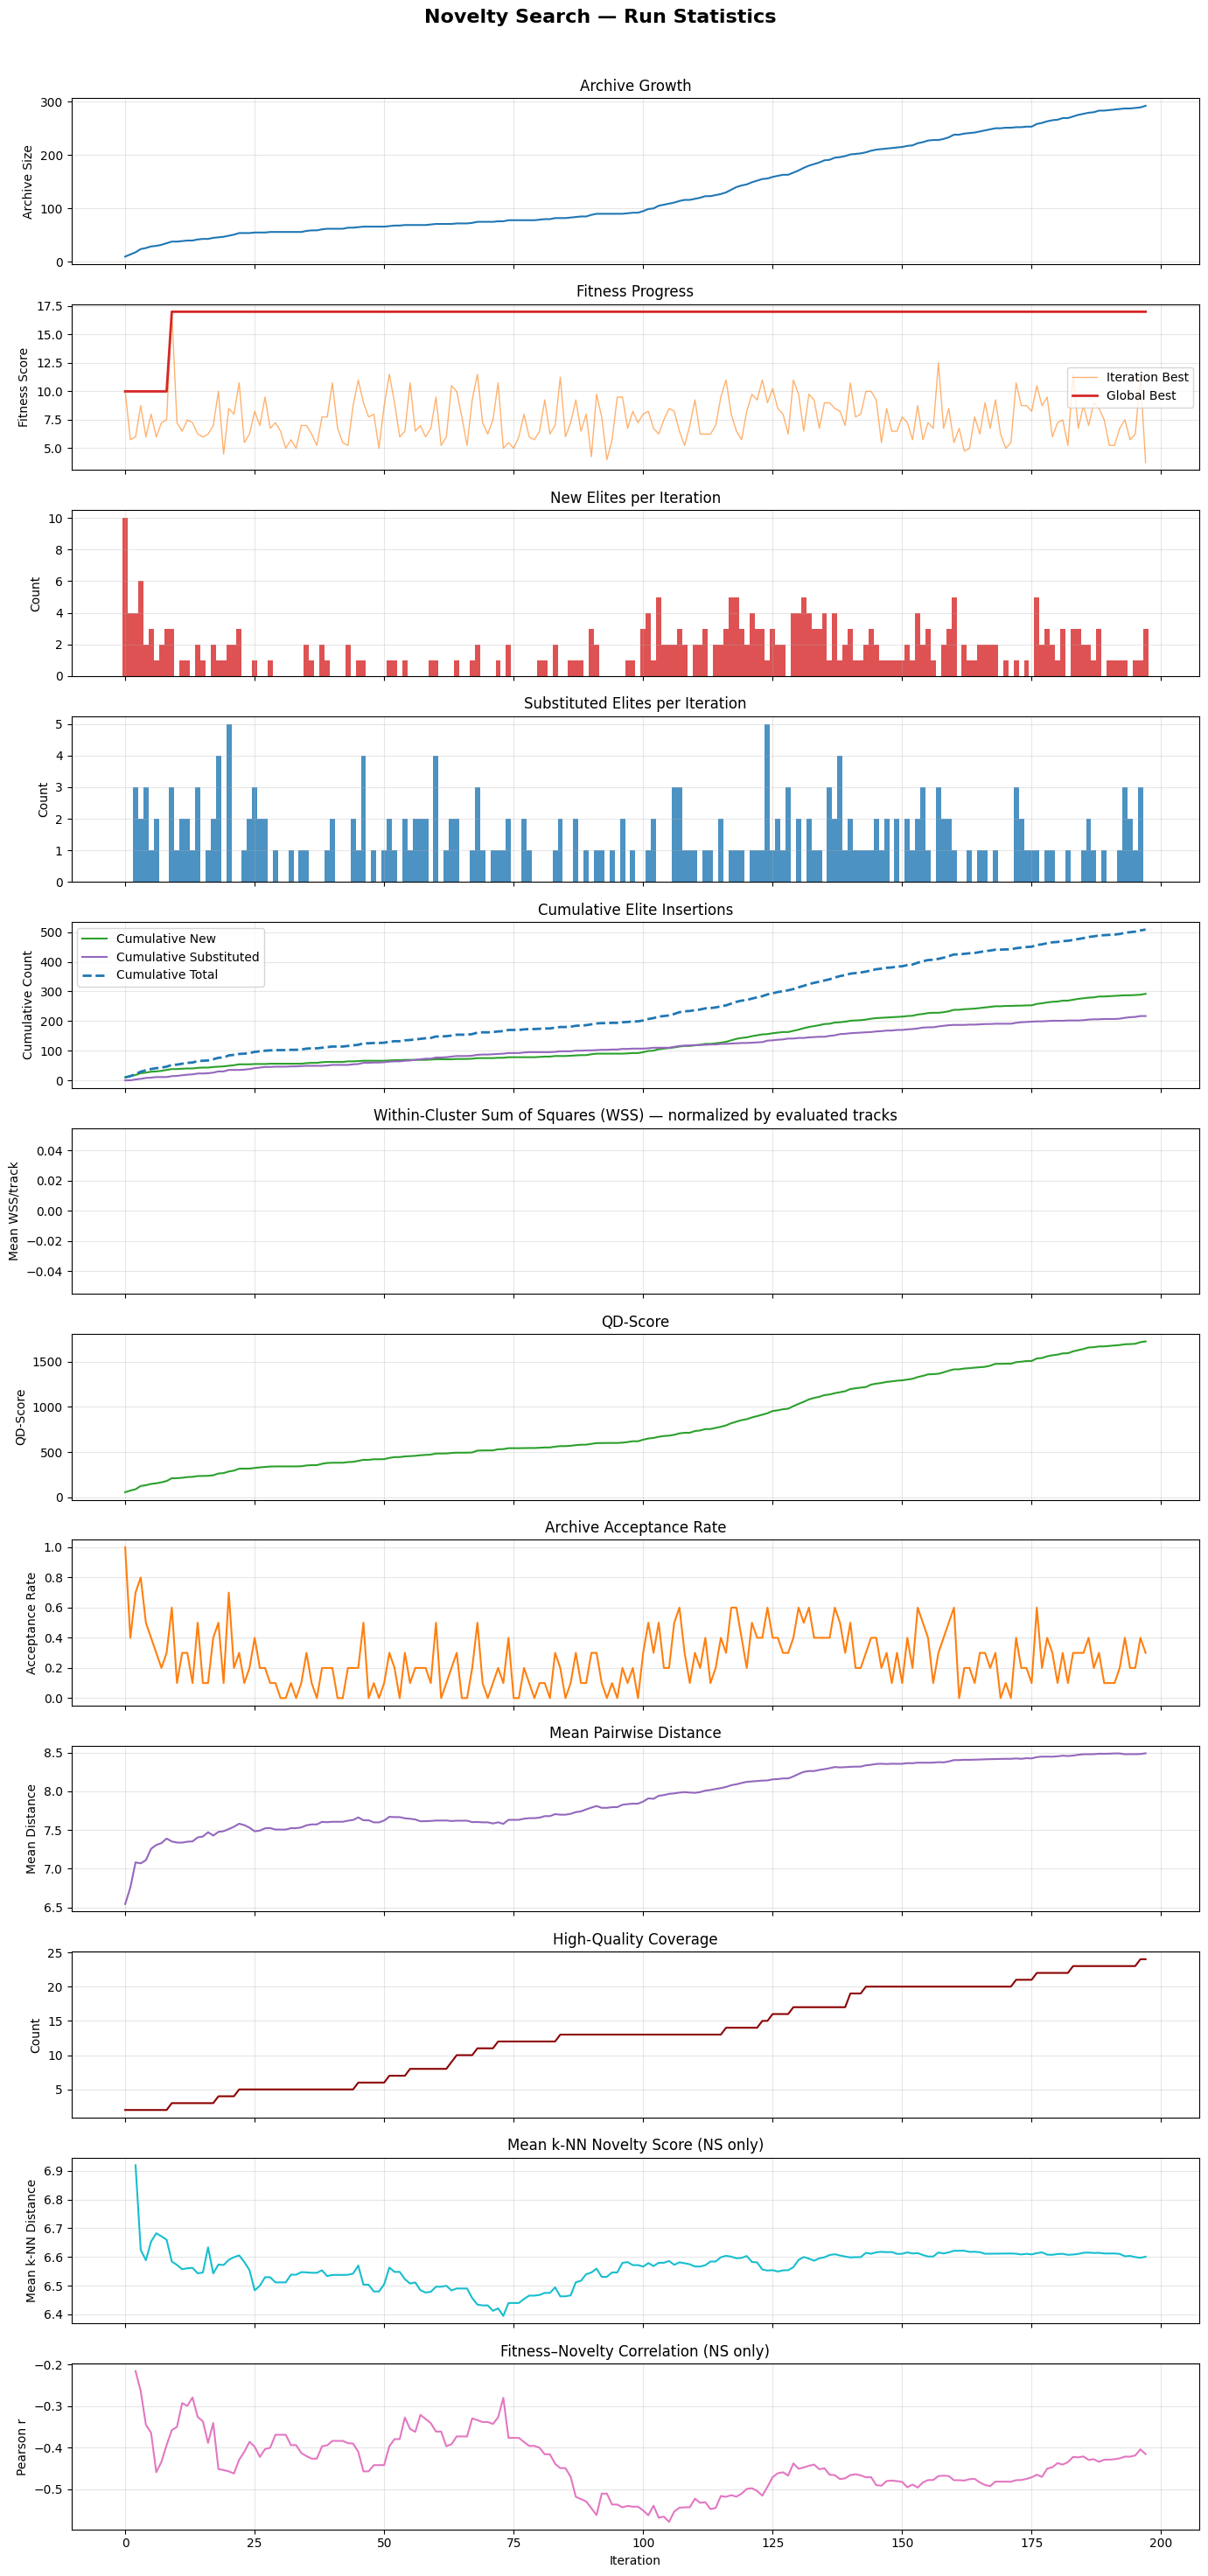

16:31:41 [INFO] Run summary | avg_new_per_iter=1.47 avg_sub_per_iter=1.10 final_archive_size=292 global_best_fitness=17.0000 title=Novelty Search total_iterations=198 total_new_elites=292 total_substituted=217


In [ ]:
runner.visualizer.plot_stats(title="Novelty Search", stats_dir=NS_DIR)

In [ ]:
runner.visualizer.export_elites(
    output_path=ELITES_OUTPUT,
    algorithm_label=ALGORITHM_LABEL,
    seed=SEED
)

15:02:52 [INFO] Elites exported | best_fitness=19.0000 best_id=546.1582599129292 count=661 file_kb=7311.7 path=data/ns/elites.json worst_fitness=1.0000
